# 🔵 TP3 | Inteligência Artificial: Model LifeCycle

**Bem-vindos ao TP3!**

Este conjunto de exercícios foi cuidadosamente elaborado para avaliar e aprimorar suas competências no desenvolvimento de modelos de Aprendizagem de Máquina. Neste TP você vai resolver exercícios para demonstrar sua competência em comparar o desempenho de modelos de aprendizagem de máquina.

Para realizar os exercícios, você utilizará o [Dataset de Obesidade do repositório UCI](https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition). Antes de iniciar o exercício, leia a descrição do dataset para entender o significado dos exemplos.

**Instruções de entrega:**
* Todas as respostas (textuais ou código-fonte) devem estar contidas em um notebook do Google Colab;
* O nome do notebook deve estar no formato nome_sobrenome_DR1_TP3;
* Respostas textuais devem ser respondidas em markdowns e respostas de código-fonte devem ser respondidas em seções de código-fonte no Google Colab;
* Identifique claramente cada exercício e sua resposta;
* Certifique-se que qualquer código-fonte esteja executando corretamente no Google Colab;
* No moodle, apenas um pdf deve ser postado contendo o link para o Google Colab;

## ⤵️ Imports

In [ ]:
!pip install ucimlrepo

In [ ]:
from sklearn.model_selection import train_test_split, cross_validate, cross_val_score, cross_val_predict
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from ucimlrepo import fetch_ucirepo
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [ ]:
obesity_df = fetch_ucirepo(id=544)

X = obesity_df.data.features
y = obesity_df.data.targets

In [ ]:
X.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation


**Variables Table**

| Name | Role | Type | Missing Values | Description |
|-----|-----|-----|-----|-----|
| Gender | Feature | Categorical | No | Gender of the individual |
| Age | Feature | Continuous | No | Age of the individual |
| Height | Feature | Continuous | No | Height of the individual |
| Weight | Feature | Continuous | No | Weight of the individual |
| family_history_with_overweight | Feature | Binary | No | Whether a family member has suffered from overweight |
| FAVC | Feature | Binary | No | Frequent consumption of high-calorie food |
| FCVC | Feature | Integer | No | Frequency of vegetable consumption |
| NCP | Feature | Continuous | No | Number of main meals per day |
| CAEC | Feature | Categorical | No | Consumption of food between meals |
| SMOKE | Feature | Binary | No | Smoking habit |
| CH2O | Feature | Continuous | No | Daily water consumption |
| SCC | Feature | Binary | No | Monitoring of calorie consumption |
| FAF | Feature | Continuous | No | Frequency of physical activity |
| TUE | Feature | Integer | No | Time using technological devices |
| CALC | Feature | Categorical | No | Alcohol consumption frequency |
| MTRANS | Feature | Categorical | No | Mode of transportation used |
| NObeyesdad | Target | Categorical | No | Obesity level classification |

## ⏳  Fases do Aprendizado de Máquina

#### 📍 **Exercício 01:**
Crie um DataFrame pandas a partir do Dataset de Obesidade e prepare-o para utilização, removendo todos os exemplos que contenham valores de atributos nulos e substituindo quaisquer valores nominais por valores numéricos.

💡 Remoção de valores nulos

In [ ]:
print('Number of missing values for each column in X (features)')
X.isna().sum()

Number of missing values for each column in X (features)


,0
Gender,0
Age,0
Height,0
Weight,0
family_history_with_overweight,0
FAVC,0
FCVC,0
NCP,0
CAEC,0
SMOKE,0


💡 Vetorização de variáveis categóricas

In [ ]:
categorical_features = ['Gender', 'CAEC', 'CALC', 'MTRANS']

for col in X[categorical_features]:
    print(f"{col}: {X[col].nunique()} categorias")
    print(X[col].value_counts())

Gender: 2 categorias
Gender
Male      1068
Female    1043
Name: count, dtype: int64
CAEC: 4 categorias
CAEC
Sometimes     1765
Frequently     242
Always          53
no              51
Name: count, dtype: int64
CALC: 4 categorias
CALC
Sometimes     1401
no             639
Frequently      70
Always           1
Name: count, dtype: int64
MTRANS: 5 categorias
MTRANS
Public_Transportation    1580
Automobile                457
Walking                    56
Motorbike                  11
Bike                        7
Name: count, dtype: int64


In [ ]:
X_vec = pd.get_dummies(X, columns=categorical_features, drop_first=True)

In [ ]:
binary_features = ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']

for col in X_vec[binary_features]:
  X_vec[col] = X[col].str.replace('yes', 'True').str.replace('no', 'False').astype('bool')

In [ ]:
X_vec.head()

,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,SMOKE,CH2O,SCC,...,CAEC_Frequently,CAEC_Sometimes,CAEC_no,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,21.0,1.62,64.0,True,True,2.0,3.0,True,2.0,True,...,False,True,False,False,False,True,False,False,True,False
1,21.0,1.52,56.0,True,True,3.0,3.0,True,3.0,True,...,False,True,False,False,True,False,False,False,True,False
2,23.0,1.80,77.0,True,True,2.0,3.0,True,2.0,True,...,False,True,False,True,False,False,False,False,True,False
3,27.0,1.80,87.0,True,True,3.0,3.0,True,2.0,True,...,False,True,False,True,False,False,False,False,False,True
4,22.0,1.78,89.8,True,True,2.0,1.0,True,2.0,True,...,False,True,False,False,True,False,False,False,True,False


***

#### 📍 **Exercício 02:**
Divida o Dataset de Obesidade em três conjuntos: conjunto de treino, conjunto de validação e conjunto de teste.

In [ ]:
train_f, test_f, train_t, test_t = train_test_split(X_vec, y, test_size=0.4, stratify=y, random_state=42)
val_f, test_f, val_t, test_t = train_test_split(test_f, test_t, test_size=0.5, stratify=test_t, random_state=42)

***

#### 📍 **Exercício 03:**
Treine modelos de Classificação K-NN para 50 diferentes valores de K igualmente espaçados no intervalo [2, 100].

#### 📍 **Exercício 04:**
Avalie a taxa de erro para cada valor de K para o conjunto de validação.

In [ ]:
k_value = np.linspace(2, 100, 50, dtype=int)
accuracy_list = []

for k in k_value:
  knn = KNeighborsClassifier(n_neighbors=k)
  knn.fit(train_f, train_t)
  accuracy_list.append(
    {
      'k_neighbors':k,
      'accuracy':accuracy_score(val_t, knn.predict(val_f)),
      'error':1-accuracy_score(val_t, knn.predict(val_f))
    }
  )

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for 

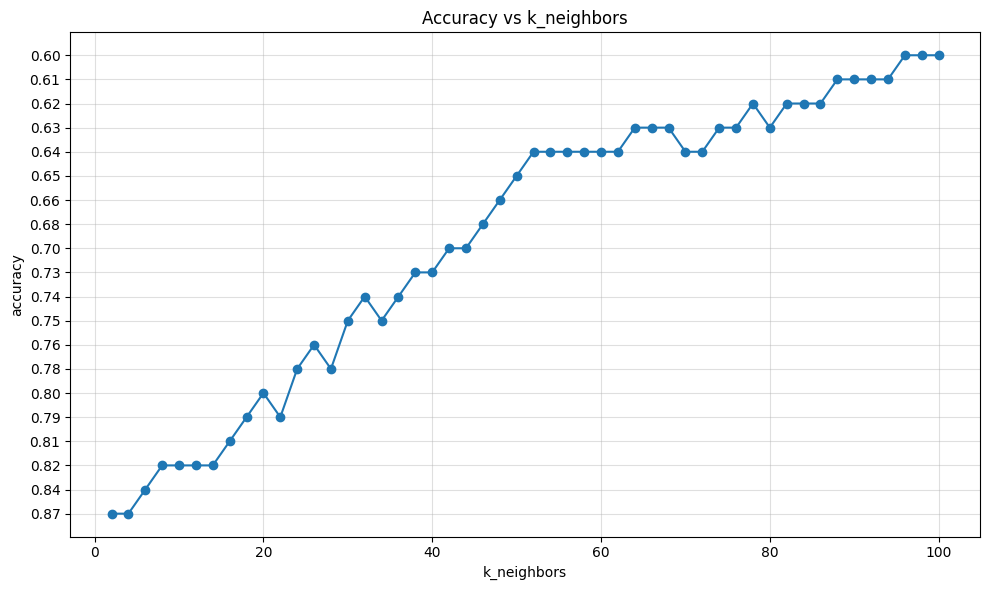

In [ ]:
y = [f"{item['accuracy']:.2f}" for item in accuracy_list]

plt.figure(figsize=(10, 6))
plt.plot(k_value, y, marker='o')
plt.grid(alpha=0.4)
plt.title('Accuracy vs k_neighbors')
plt.xlabel('k_neighbors')
plt.ylabel('accuracy')

plt.tight_layout()
plt.show()

**⚠️ MUITA ATENÇÃO!**

O melhor valor para k, baseado na acurácia, é k = 2 (ou 4), com acurácia de 87%. Utilizaremos k = 2.

***

#### 📍 **Exercício 05:**
Avalie o valor de K que apresentou o melhor desempenho com o conjunto de teste.

In [ ]:
knn = KNeighborsClassifier(n_neighbors=2)
knn.fit(train_f, train_t)
predicted = knn.predict(test_f)
accuracy = accuracy_score(test_t, predicted)

print(f'Acurácia (k=2): {accuracy:.4f}%\n')

Acurácia (k=2): 0.8652%



/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


***

#### 📍 **Exercício 06:**
Imprima todos os valores de K e das métricas utilizadas para avaliar a taxa de erro. Além disso, indique qual foi o melhor valor de K.

In [ ]:
print(pd.DataFrame(accuracy_list).sort_values(by='accuracy',ascending=False))

    k_neighbors  accuracy     error
0             2  0.872038  0.127962
1             4  0.872038  0.127962
2             6  0.843602  0.156398
4            10  0.824645  0.175355
3             8  0.822275  0.177725
6            14  0.822275  0.177725
5            12  0.819905  0.180095
7            16  0.808057  0.191943
9            20  0.803318  0.196682
8            18  0.793839  0.206161
10           22  0.786730  0.213270
11           24  0.779621  0.220379
13           28  0.777251  0.222749
12           26  0.763033  0.236967
14           30  0.753555  0.246445
16           34  0.748815  0.251185
15           32  0.741706  0.258294
17           36  0.739336  0.260664
18           38  0.727488  0.272512
19           40  0.727488  0.272512
20           42  0.703791  0.296209
21           44  0.701422  0.298578
22           46  0.680095  0.319905
23           48  0.656398  0.343602
24           50  0.649289  0.350711
25           52  0.644550  0.355450
34           70  0.642180  0

***

## 🛠️ Overfitting, Underfitting e Generalização

#### 📍 **Exercício 01:**
Divida o Dataset de Obesidade em dois conjuntos: conjunto de treinamento e conjunto de teste.

In [ ]:
y = obesity_df.data.targets

In [ ]:
train_f, test_f, train_t, test_t = train_test_split(X_vec, y, test_size=0.4, stratify=y, random_state=42)

***

#### 📍 **Exercício 02:**
Adicione um ruído para cada valor do atributo `Weight`. Este ruído deve ser uniforme, variando no intervalo [-100, 100].

In [ ]:
train_f['Weight'] = train_f['Weight'] + np.random.uniform(-100, 100, size=len(train_f))

***

#### 📍 **Exercício 03:**
Treine modelos de Classificação K-NN para 50 diferentes valores de K igualmente espaçados no intervalo [2, 100].

#### 📍 **Exercício 04:**
Avalie a métrica acurácia para cada valor de K para o conjunto de treino e guarde em uma lista chamada acuracias_treino.

#### 📍 **Exercício 05:**
Avalie a métrica acurácia para cada valor de K para o conjunto de teste e guarde em uma lista chamada acuracias_teste.

In [ ]:
acuracias_treino = []
acuracias_teste = []

k_value = np.linspace(2, 100, 50, dtype=int)

for k in k_value:
  knn = KNeighborsClassifier(n_neighbors=k)
  knn.fit(train_f, train_t)

  pred_train = knn.predict(train_f)
  accuracy_train = accuracy_score(train_t, pred_train)

  pred_test = knn.predict(test_f)
  accuracy_test = accuracy_score(test_t, pred_test)

  acuracias_treino.append({'k_neighbors': k, 'accuracy': accuracy_train})
  acuracias_teste.append({'k_neighbors': k, 'accuracy': accuracy_test})

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for 

***

In [ ]:
df_treino = pd.DataFrame(acuracias_treino)
df_teste = pd.DataFrame(acuracias_teste)

#### 📍 **Exercício 06:**
Plote um gráfico com os valores de K no eixo-x e as acurácias de treinamento e teste no eixo-y. As acurácias de treinamento e teste devem ser plotadas nas cores verde e azul, respectivamente.

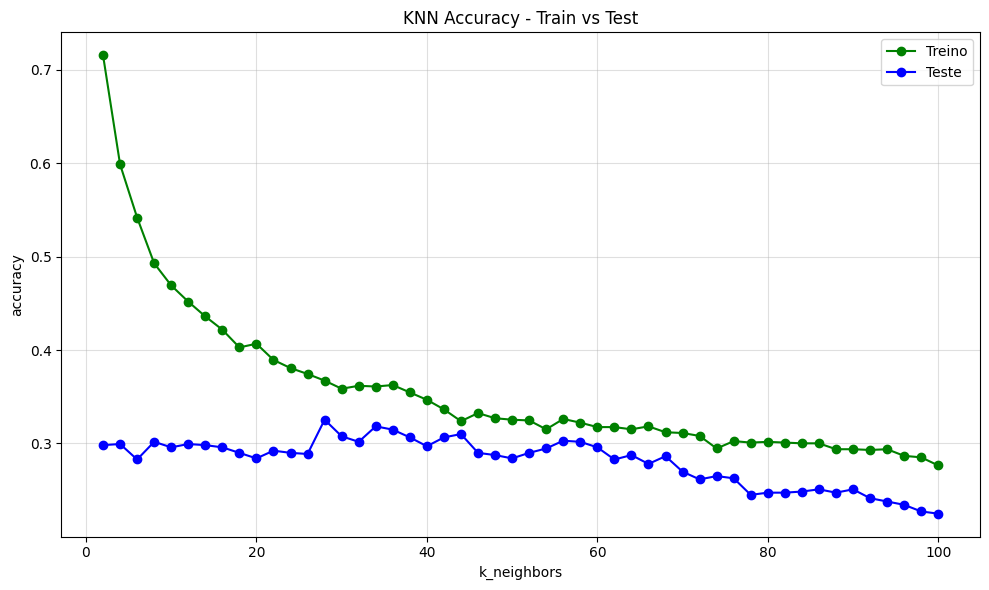

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(df_treino['k_neighbors'], df_treino['accuracy'], marker='o', color='green', label='Treino')
plt.plot(df_teste['k_neighbors'], df_teste['accuracy'], marker='o', color='blue', label='Teste')

plt.grid(alpha=0.4)
plt.title('KNN Accuracy - Train vs Test')
plt.xlabel('k_neighbors')
plt.ylabel('accuracy')

plt.tight_layout()
plt.legend()
plt.show()

***

#### 📍 **Exercício 07:**
Assuma que uma acurácia menor do que 50% corresponde a uma baixa complexidade do modelo. Para algum valor de K, ocorreu overfitting ou underfitting? Se sim, a partir de qual valor de K? O modelo generalizou para algum valor de K? Qual valor e por quê? Justifique sua resposta com informações do gráfico.

In [ ]:
print('--- Treino ---\n',df_treino)
print('\n--- Teste ---\n',df_teste)

--- Treino ---
     k_neighbors  accuracy
0             2  0.715640
1             4  0.598736
2             6  0.541864
3             8  0.492891
4            10  0.469194
5            12  0.451817
6            14  0.436019
7            16  0.421801
8            18  0.402844
9            20  0.406793
10           22  0.389415
11           24  0.380727
12           26  0.374408
13           28  0.367299
14           30  0.358610
15           32  0.361769
16           34  0.360979
17           36  0.362559
18           38  0.354660
19           40  0.346761
20           42  0.336493
21           44  0.323855
22           46  0.332543
23           48  0.327014
24           50  0.325434
25           52  0.324645
26           54  0.315166
27           56  0.326224
28           58  0.322275
29           60  0.317536
30           62  0.317536
31           64  0.315166
32           66  0.318325
33           68  0.312006
34           70  0.311216
35           72  0.308057
36           74  0.294

***

## 📝 Validação Cruzada e Variância de Modelo

#### 📍 **Exercício 01:**
Divida o Dataset de Obesidade em dois conjuntos: conjunto de treinamento e conjunto de teste.

In [ ]:
train_f, test_f, train_t, test_t = train_test_split(X_vec, y, test_size=0.4, stratify=y, random_state=42)

***

#### 📍 **Exercício 02:**
Treine modelos de Classificação K-NN para 50 diferentes valores de K igualmente espaçados no intervalo [2, 100].

#### 📍 **Exercício 03:**
Realize Validação Cruzada de 5-folds para cada valor de K.

In [ ]:
cross_validate_list = []

k_value = np.linspace(2, 100, 50, dtype=int)

for k in k_value:
  knn = KNeighborsClassifier(n_neighbors=k)
  results = cross_val_score(knn, train_f, train_t, cv=5, scoring='accuracy')

  cross_validate_list.append(
      {
          'k_neighbors': k,
          'accuracy': results.mean(),
          'erro': 1 - results.mean(),
          'std': results.std()
      }
  )

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for 

***

#### 📍 **Exercício 04:**
Mostre os erros de classificação e **variância do modelo**.

In [ ]:
df_results = pd.DataFrame(cross_validate_list)
df_results

,k_neighbors,accuracy,erro,std
0,2,0.860982,0.139018,0.018250
1,4,0.838869,0.161131,0.028065
2,6,0.820700,0.179300,0.028096
3,8,0.799371,0.200629,0.029064
4,10,0.774881,0.225119,0.025001
5,12,0.763832,0.236168,0.029433
6,14,0.752762,0.247238,0.028146
7,16,0.745651,0.254349,0.026688
8,18,0.737761,0.262239,0.016620
9,20,0.723554,0.276446,0.022576


***

#### 📍 **Exercício 05:**
Plote um gráfico em que no eixo-x estão dispostos os valores de k e no eixo-y a variância do modelo. Interprete o gráfico e indique como/se o parâmetro K influencia na variância do modelo.

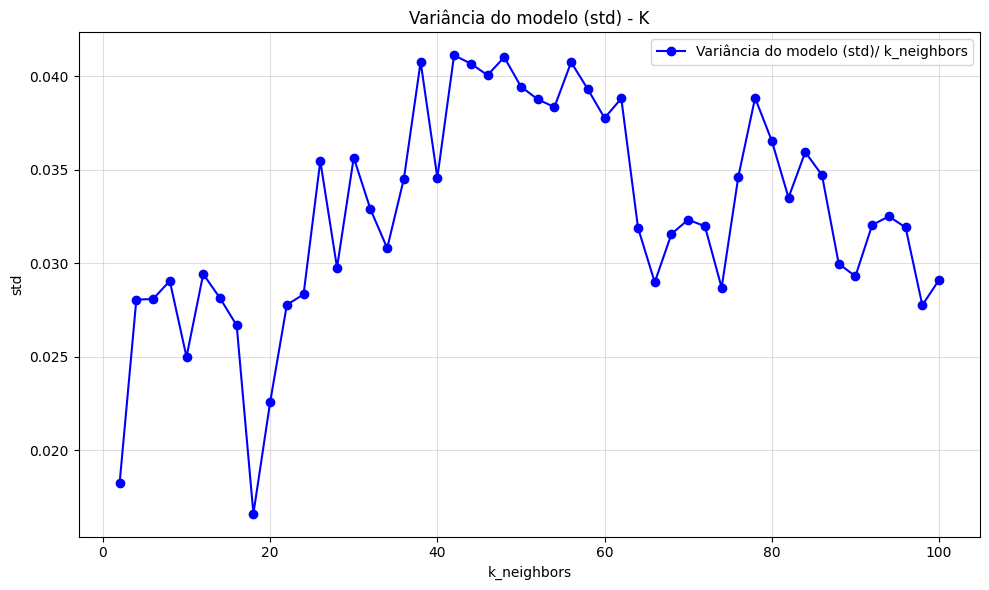

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(df_results['k_neighbors'], df_results['std'], color='blue', marker='o', label='Variância do modelo (std)/ k_neighbors')

plt.grid(alpha=0.4)
plt.title('Variância do modelo (std) - K')
plt.xlabel('k_neighbors')
plt.ylabel('std')

plt.tight_layout()
plt.legend()
plt.show()

O gráfico mostra que a estabilidade do modelo varia conforme o valor de K.

Alguns valores apresentam maior variação entre os folds (k_neighbors mais altos), menos consistentes, enquanto outros são mais estáveis. Embora valores maiores de K tendam a gerar modelos mais estáveis, isso não ocorre de forma perfeitamente linear neste caso. Quando olhamos valores de K mais baixos (entre 1 a 20), o modelo tende a overfitting. Ou seja, se adequa tanto aos dados, ao ponto da variação entre os folds ser baixíssima.

Portanto, o ideal é escolher um K que combine boa acurácia com baixa variação, garantindo um modelo mais confiável.

***